# Ablation Diagnostics

Trimmed diagnostics for comparing Samudra LLC ablation rollouts against LLC4320.

In [7]:
import os
from pathlib import Path

import cftime
import dask
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr


## Configuration

In [14]:
# ============== LOAD LLC ==============
# Same LLC loading pattern used in prognostic_var_comparison_+gradients.ipynb.
llc_store = '/orcd/data/abodner/003/LLC4320/LLC4320'
llc_face = 1
llc_i_slice = slice(2880, 3600)
llc_j_slice = slice(720, 1440)

# ============== LOAD EMULATORS / ABLATIONS ==============
# Edit this list as new ablation runs finish repacking to predictions_4d.zarr.
emulator_configs = [
    {
        'name': 'baseline',
        'key': 'baseline',
        'path': '/orcd/data/abodner/002/cody/inference_patch/curriculum/ablations/2026-07-01-eval:Samudra_LLC:ablation-mid-false_skip-keep_convnextres-false-16960975/predictions_4d.zarr',
        'desc': 'no runtime ablation',
    },
    {
        'name': 'middle_core_off',
        'key': 'middle_core_off',
        'path': '/orcd/data/abodner/002/cody/inference_patch/curriculum/ablations/2026-07-01-eval:Samudra_LLC:ablation-middle_core-mid-true_skip-keep_convnextres-false-16961066/predictions_4d.zarr',
        'desc': 'U-Net middle CoreBlock bypassed',
    },
    {
        'name': 'skip_all_off',
        'key': 'skip_all_off',
        'path': '/orcd/data/abodner/002/cody/inference_patch/curriculum/ablations/2026-07-01-eval:Samudra_LLC:ablation-skip-all-mid-false_skip-drop_all_convnextres-false-16961076/predictions_4d.zarr',
        'desc': 'all U-Net skip additions disabled',
    },
]

selected_time_range = [0, 56]   # inclusive indices after common-time matching
stepping = 1                    # 1 = every timestep, 4 = every 4th timestep

prognostic_vars = ['Theta', 'Salt', 'U', 'V']
thermo_vars = ['Theta', 'Salt']
dynamic_vars = ['U', 'V']
max_depth_levels = 51

depth_plot_step = 47
gradient_snapshot_steps = [0, 17, 34, 47]
high_gradient_percentile = 97.5

out_dir = Path('figs/ablations')
out_dir.mkdir(parents=True, exist_ok=True)


## Helpers

In [9]:
def format_time(t_val):
    try:
        return f'{t_val.day:02d}/{t_val.month:02d}/{t_val.year}:{t_val.hour:02d}h'
    except AttributeError:
        t_pd = pd.Timestamp(t_val)
        return f'{t_pd.day:02d}/{t_pd.month:02d}/{t_pd.year}:{t_pd.hour:02d}h'


def normalize_times(times):
    return pd.DatetimeIndex([
        pd.Timestamp(
            int(t.year), int(t.month), int(t.day),
            int(t.hour), int(t.minute), int(t.second)
        )
        if hasattr(t, 'year')
        else pd.Timestamp(t).floor('s')
        for t in times
    ])


def as_dask(x):
    return x.data if isinstance(x.data, da.Array) else da.from_array(x.data)


def safe_norm(num, den):
    return da.where((den == 0) | da.isnan(den), np.nan, num / den)


def require_time_steps(requested_steps, n_times, label):
    missing = [int(t) for t in requested_steps if int(t) < 0 or int(t) >= n_times]
    if missing:
        raise ValueError(
            f'{label} requested time index/indices {missing}, but synchronized data '
            f'only has indices 0..{n_times - 1}. Adjust selected_time_range, run a longer '
            'rollout, or lower the configured diagnostic step(s).'
        )


def emulator_palette(n):
    cmap = plt.get_cmap('tab10') if n <= 10 else plt.get_cmap('tab20')
    return [cmap(i % cmap.N) for i in range(n)]


def get_depth_meters(patch):
    if 'Z' in patch:
        z = patch['Z'].values
        return np.abs(np.round(z).astype(float))
    if 'k' in patch.coords:
        return patch['k'].values.astype(float)
    return np.arange(patch.sizes['k'], dtype=float)


## Load, Time-Match, And Trim

In [10]:
llc_patch_full = xr.open_zarr(
    llc_store,
    consolidated=False,
)

# LLC velocity variables live on staggered horizontal dims:
# U -> i_g and V -> j_g. Crop both regular and staggered dims so all
# prognostic variables become 720 x 720 before converting to dask arrays.
llc_crop_indexers = {'face': llc_face}
for dim_name, dim_slice in {
    'i': llc_i_slice,
    'i_g': llc_i_slice,
    'j': llc_j_slice,
    'j_g': llc_j_slice,
}.items():
    if dim_name in llc_patch_full.dims:
        llc_crop_indexers[dim_name] = dim_slice

llc_patch_full = llc_patch_full.isel(llc_crop_indexers)

for var in prognostic_vars:
    if var in llc_patch_full:
        print(f'LLC {var} dims after crop: {llc_patch_full[var].dims}, shape={llc_patch_full[var].shape}')

emulator_patches_raw = {}
for cfg in emulator_configs:
    emulator_patches_raw[cfg['key']] = xr.open_dataset(cfg['path'], consolidated=True)
    print(f"Loaded {cfg['name']}: {cfg['desc']}")

llc_times_norm = normalize_times(llc_patch_full.time.values)
common_times = llc_times_norm
for cfg in emulator_configs:
    emulator_times_norm = normalize_times(emulator_patches_raw[cfg['key']].time.values)
    common_times = common_times.intersection(emulator_times_norm)
common_times = common_times.sort_values()

llc_mask = llc_times_norm.isin(common_times)
llc_patch = llc_patch_full.isel(time=llc_mask)
print(f'LLC subset to {len(common_times)} common times')

grid_vars = ['XC', 'YC', 'rA', 'Z']
emulator_patches = {}
for cfg in emulator_configs:
    patch_raw = emulator_patches_raw[cfg['key']]
    patch_times_norm = normalize_times(patch_raw.time.values)
    patch_mask = patch_times_norm.isin(common_times)
    patch = patch_raw.isel(time=patch_mask)

    for gv in grid_vars:
        patch[gv] = llc_patch[gv]

    emulator_patches[cfg['key']] = patch

emulator_info = [(cfg['name'], cfg['key']) for cfg in emulator_configs]
n_emulators = len(emulator_info)

all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f'\n=== Setup complete: LLC + {n_emulators} emulators ===')
for name, key in emulator_info:
    print(f'  {name} ({key})')


LLC Theta dims after crop: ('time', 'k', 'j', 'i'), shape=(10311, 51, 720, 720)
LLC Salt dims after crop: ('time', 'k', 'j', 'i'), shape=(10311, 51, 720, 720)
LLC U dims after crop: ('time', 'k', 'j', 'i_g'), shape=(10311, 51, 720, 720)
LLC V dims after crop: ('time', 'k', 'j_g', 'i'), shape=(10311, 51, 720, 720)
Loaded baseline: no runtime ablation
Loaded middle_core_off: U-Net middle CoreBlock bypassed
Loaded skip_all_off: all U-Net skip additions disabled
LLC subset to 48 common times

=== Setup complete: LLC + 3 emulators ===
  baseline (baseline)
  middle_core_off (middle_core_off)
  skip_all_off (skip_all_off)


In [11]:
start_idx, end_idx = selected_time_range

llc_patch = llc_patch.isel(time=slice(start_idx, end_idx + 1, stepping))

emulator_patches_subset = {}
for key, patch in emulator_patches.items():
    max_time = patch.sizes['time']
    safe_end_idx = min(end_idx, max_time - 1)
    emulator_patches_subset[key] = patch.isel(
        time=slice(start_idx, safe_end_idx + 1, stepping)
    )
emulator_patches = emulator_patches_subset

min_time_len = min(
    [llc_patch.sizes['time']] +
    [patch.sizes['time'] for patch in emulator_patches.values()]
)

llc_patch = llc_patch.isel(time=slice(0, min_time_len))
emulator_patches = {
    key: patch.isel(time=slice(0, min_time_len))
    for key, patch in emulator_patches.items()
}
all_patches = {'llc': llc_patch}
all_patches.update(emulator_patches)

print(f'Subset to time indices {start_idx}:{end_idx}')
print(f'Stepping = {stepping}')
print(f'Final synchronized length = {min_time_len}')
print(f'LLC now has {llc_patch.sizes["time"]} times')
for name, key in emulator_info:
    print(f'{name} ({key}) now has {emulator_patches[key].sizes["time"]} times')



Subset to time indices 0:56
Stepping = 1
Final synchronized length = 48
LLC now has 48 times
baseline (baseline) now has 48 times
middle_core_off (middle_core_off) now has 48 times
skip_all_off (skip_all_off) now has 48 times


## 1. Normalized Prediction Error Stability

Calculating normalized PE for U, baseline...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 47
  result = blockwise(


Calculating normalized PE for V, baseline...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 47
  result = blockwise(


Calculating normalized PE for U, middle_core_off...


...

/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 47
  result = blockwise(


Calculating normalized PE for U, skip_all_off...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 47
  result = blockwise(


Calculating normalized PE for V, skip_all_off...


/orcd/home/002/codycruz/LLC_ocean_emulator/high_res_diagnostics/.venv/lib64/python3.12/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 47
  result = blockwise(


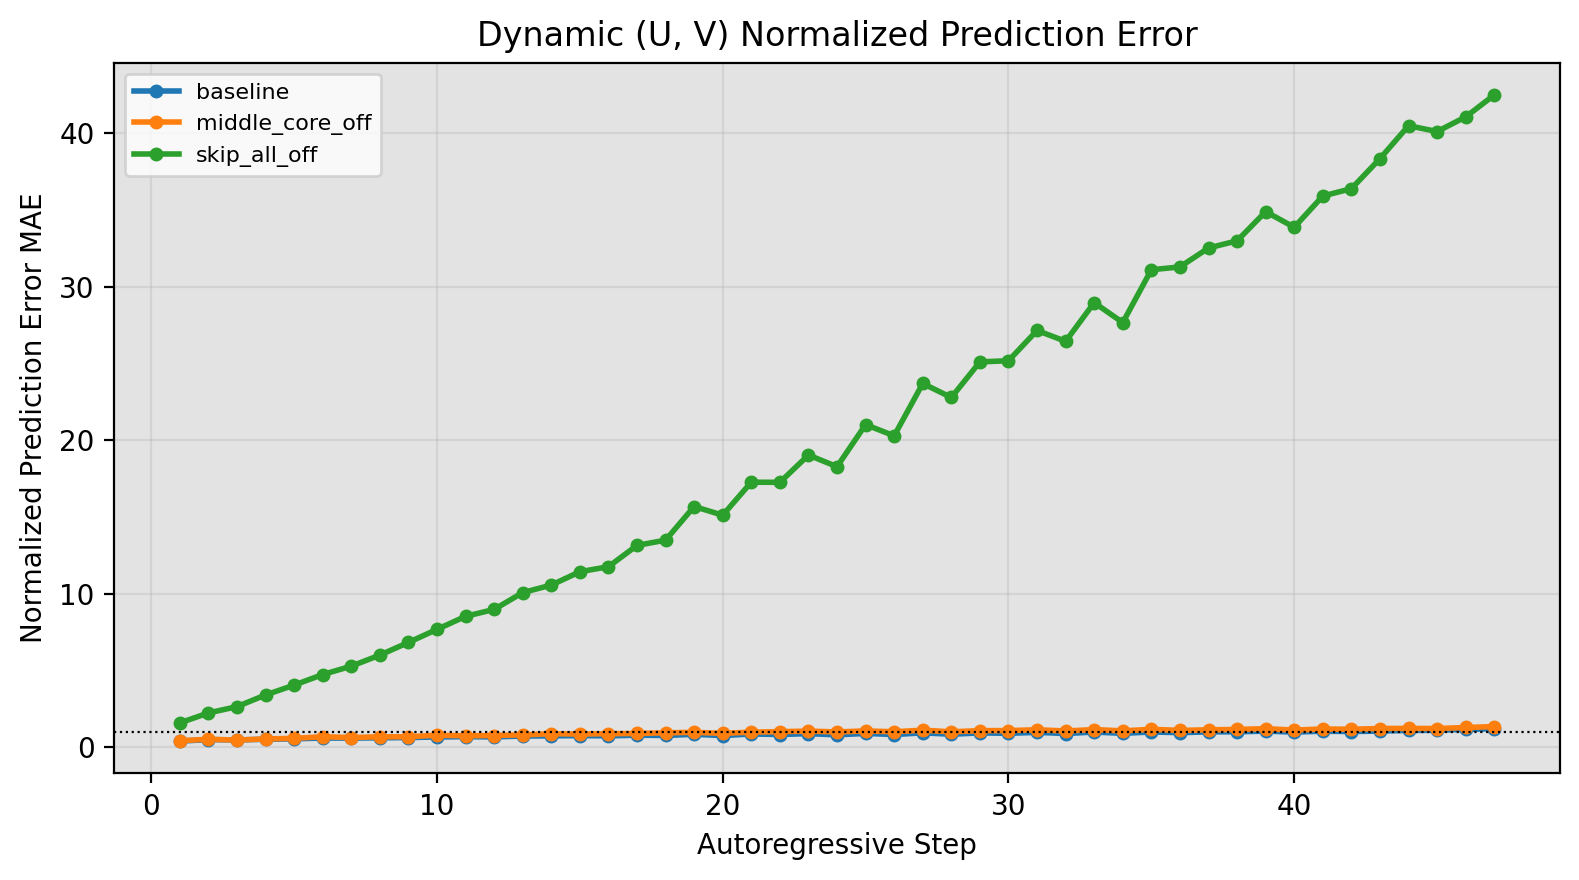

Saved figs/ablations/stability/dynamic_normalized_prediction_error.png


In [12]:
def normalized_prediction_error_by_group(group_vars):
    n_times = llc_patch.sizes['time']
    time_indices = np.arange(1, n_times)
    results = {}

    for emu_name, emu_key in emulator_info:
        pe_vars = []

        for var in group_vars:
            print(f'Calculating normalized PE for {var}, {emu_name}...')
            k_stop = min(max_depth_levels, llc_patch.sizes['k'])
            llc_depth = as_dask(llc_patch[var].isel(k=slice(0, k_stop)))
            emu_depth = as_dask(emulator_patches[emu_key][var].isel(k=slice(0, k_stop)))

            llc_t1 = llc_depth[:-1, :, :, :]
            llc_t2 = llc_depth[1:, :, :, :]
            emu_t2 = emu_depth[1:, :, :, :]

            baseline_k = da.nanmean(da.abs(llc_t2 - llc_t1), axis=(-2, -1))
            pe_k = da.nanmean(da.abs(llc_t2 - emu_t2), axis=(-2, -1))
            pe_norm_depth = da.nanmean(safe_norm(pe_k, baseline_k), axis=1)
            pe_vars.append(pe_norm_depth)

        pe_group = da.nanmean(da.stack(pe_vars, axis=0), axis=0)
        results[emu_key] = dask.compute(pe_group)[0]

    return time_indices, results


def plot_normalized_pe_group(group_vars, group_name, filename):
    stability_dir = out_dir / 'stability'
    stability_dir.mkdir(parents=True, exist_ok=True)

    time_indices, results = normalized_prediction_error_by_group(group_vars)
    colors = emulator_palette(n_emulators)

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
    for color, (emu_name, emu_key) in zip(colors, emulator_info):
        ax.plot(
            time_indices,
            results[emu_key],
            marker='o',
            linewidth=2,
            markersize=4,
            color=color,
            label=emu_name,
        )

    ax.axhline(1, color='k', linewidth=0.8, linestyle=':')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#E3E3E3')
    ax.set_xlabel('Autoregressive Step')
    ax.set_ylabel('Normalized Prediction Error MAE')
    ax.set_title(f'{group_name} Normalized Prediction Error')
    ax.legend(fontsize=8, loc='best')

    plt.tight_layout()
    out_path = stability_dir / filename
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')


plot_normalized_pe_group(thermo_vars, 'Thermo (Theta, Salt)', 'thermo_normalized_prediction_error.png')
plot_normalized_pe_group(dynamic_vars, 'Dynamic (U, V)', 'dynamic_normalized_prediction_error.png')


## 2. Median Error Vs Depth

Generating median depth-error plot for Theta at step 47...


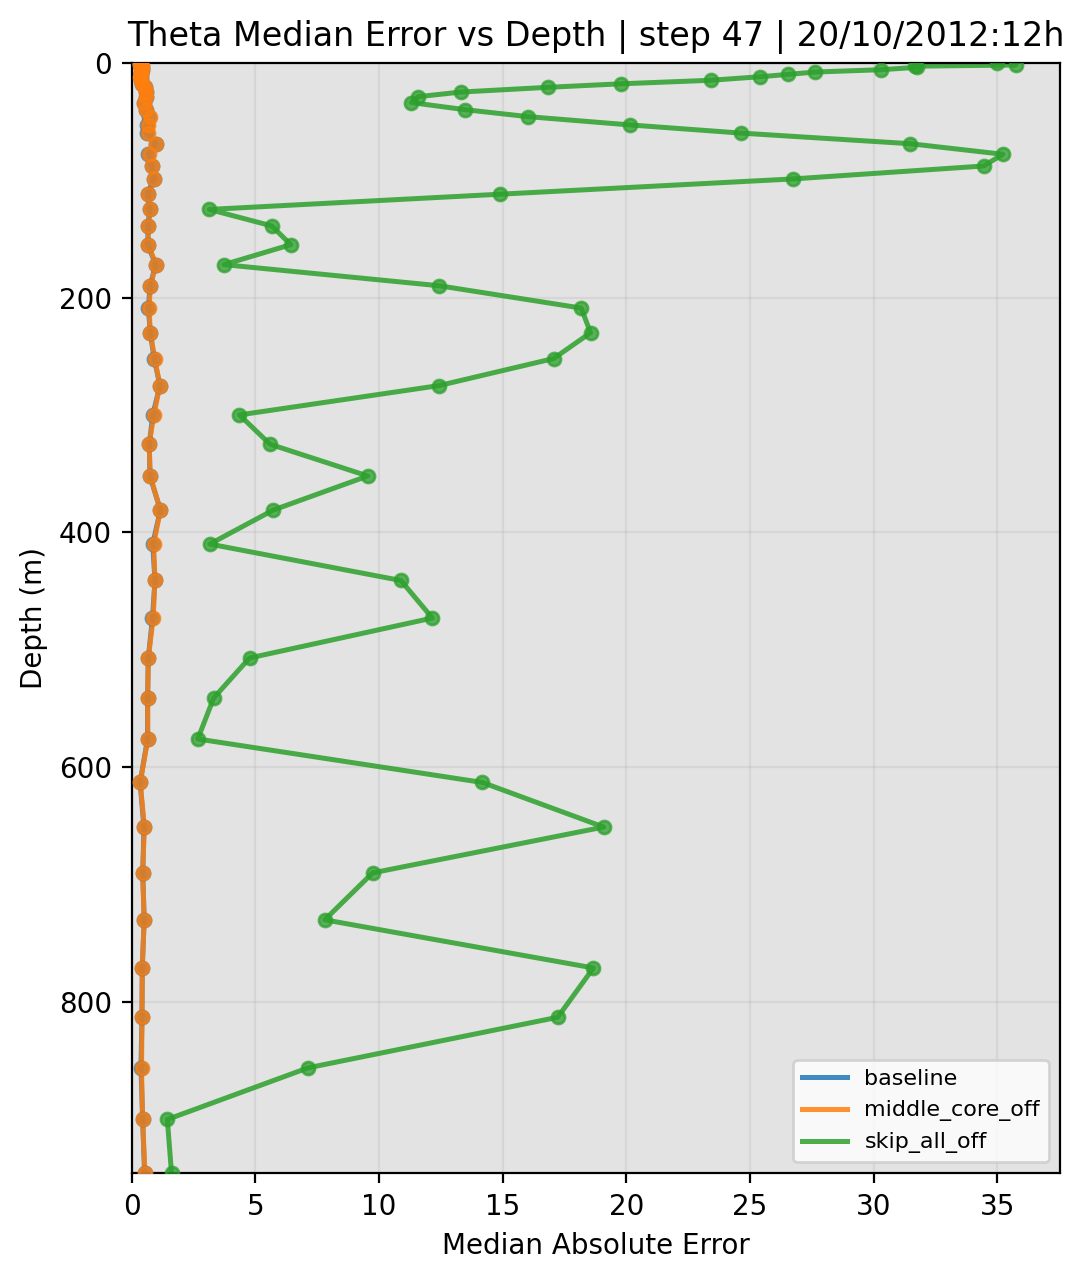

Saved figs/ablations/depth_error/Theta_median_error_vs_depth_step_047.png
Generating median depth-error plot for Salt at step 47...


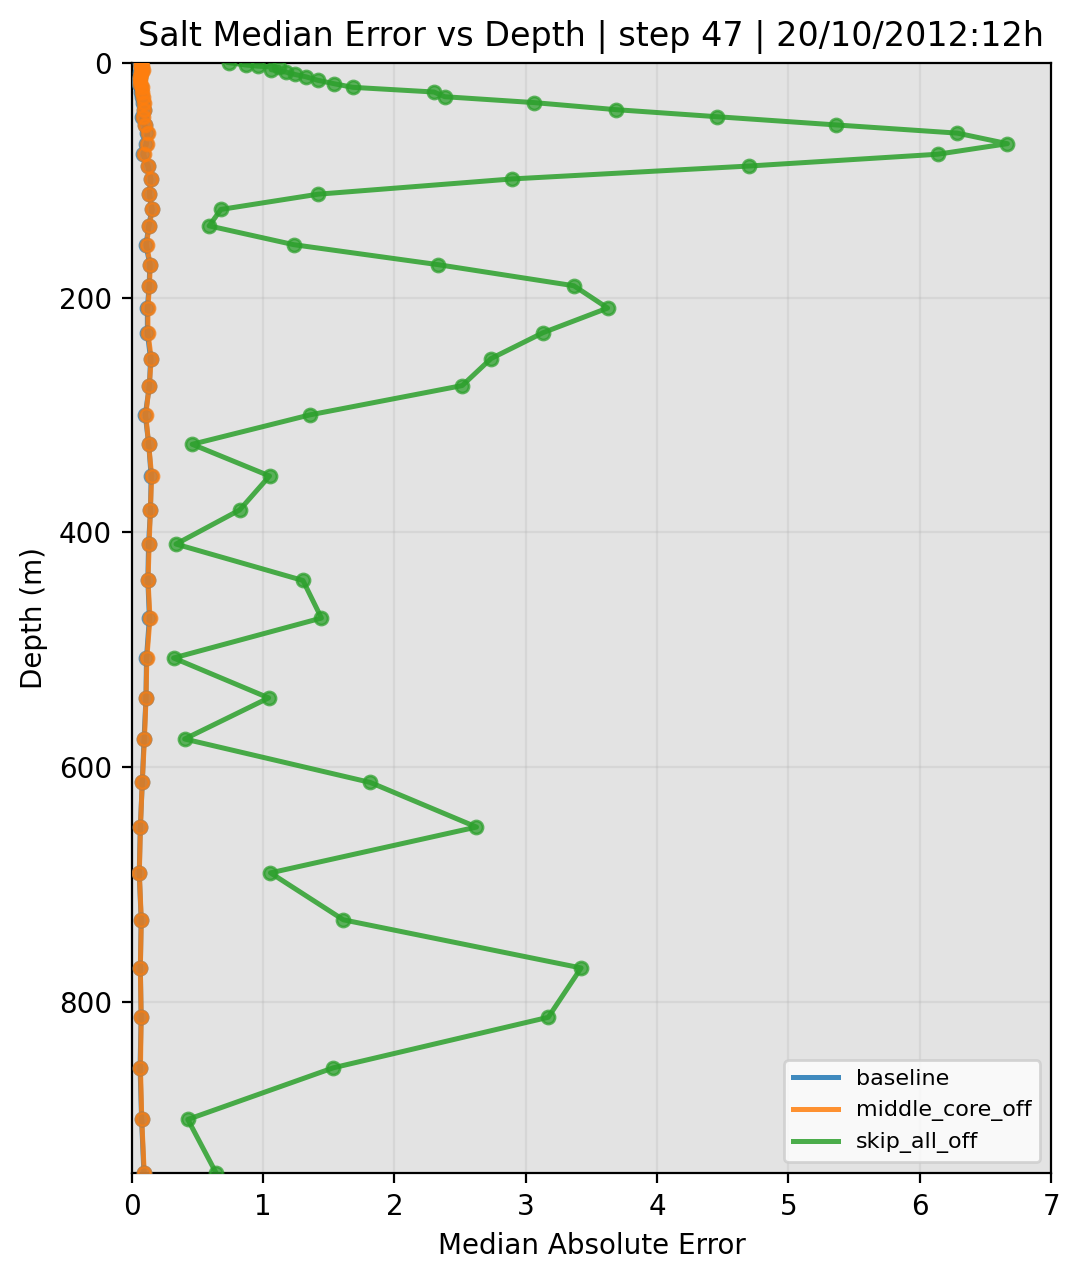

Saved figs/ablations/depth_error/Salt_median_error_vs_depth_step_047.png
Generating median depth-error plot for U at step 47...


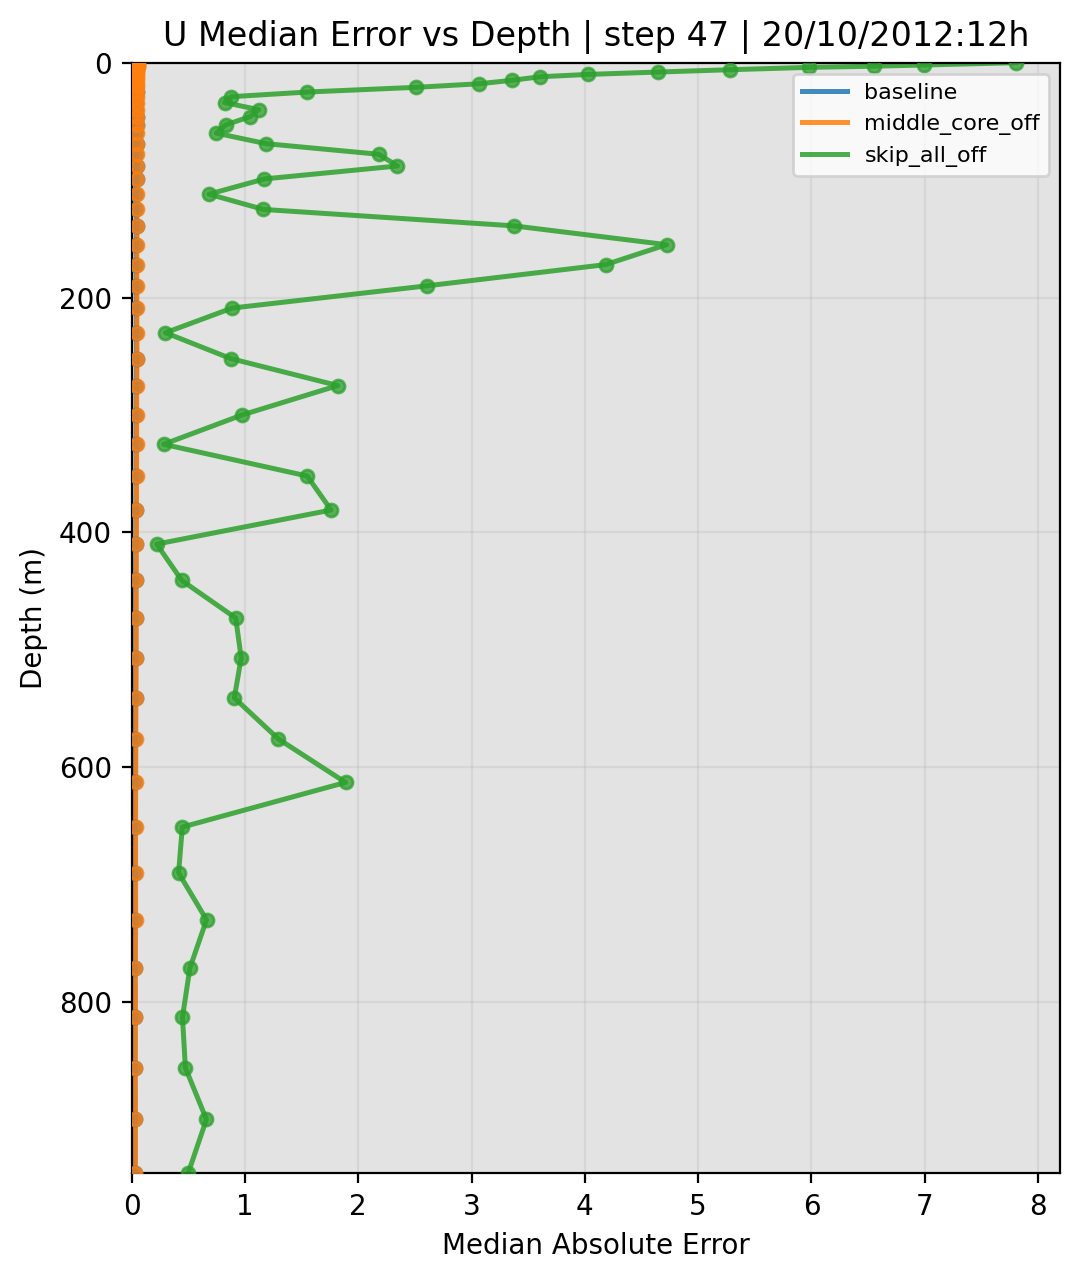

Saved figs/ablations/depth_error/U_median_error_vs_depth_step_047.png
Generating median depth-error plot for V at step 47...


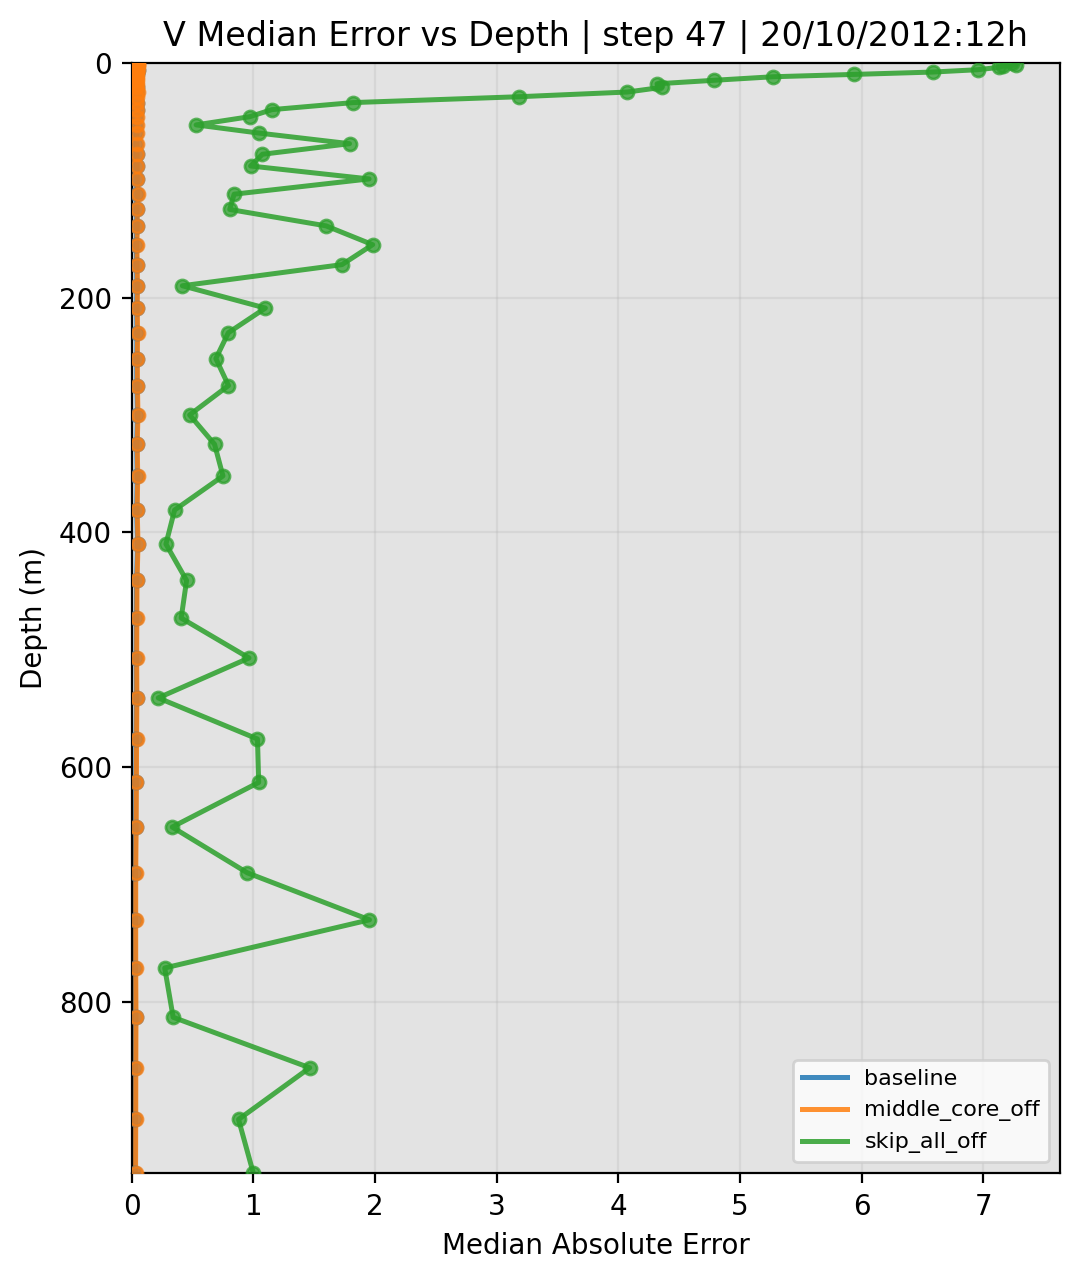

Saved figs/ablations/depth_error/V_median_error_vs_depth_step_047.png


In [15]:
def plot_median_error_vs_depth(step=depth_plot_step):
    depth_dir = out_dir / 'depth_error'
    depth_dir.mkdir(parents=True, exist_ok=True)
    require_time_steps([step], llc_patch.sizes['time'], 'Depth-error plot')

    colors = emulator_palette(n_emulators)
    depths = get_depth_meters(llc_patch)
    time_str = format_time(llc_patch.time.values[step])

    for var in prognostic_vars:
        print(f'Generating median depth-error plot for {var} at step {step}...')
        llc_data = llc_patch.isel(time=step)[var].values
        n_depths = llc_data.shape[0]

        fig, ax = plt.subplots(figsize=(5.5, 6.5), dpi=200)
        all_profiles = []

        for color, (emu_name, emu_key) in zip(colors, emulator_info):
            emu_data = emulator_patches[emu_key].isel(time=step)[var].values
            diff = np.abs(llc_data - emu_data)
            median_errors = np.nanmedian(diff.reshape(n_depths, -1), axis=1)
            all_profiles.append(median_errors)

            ax.scatter(median_errors, depths[:n_depths], color=color, s=22, alpha=0.75, zorder=3)
            ax.plot(median_errors, depths[:n_depths], color=color, linewidth=1.8, alpha=0.85, label=emu_name)

        xmax = np.nanmax(np.concatenate(all_profiles)) * 1.05
        ax.set_xlim(0, xmax if np.isfinite(xmax) and xmax > 0 else 1)
        ax.set_ylim(np.nanmax(depths[:n_depths]), 0)
        ax.grid(alpha=0.25)
        ax.set_facecolor('#E3E3E3')
        ax.set_xlabel('Median Absolute Error')
        ax.set_ylabel('Depth (m)')
        ax.set_title(f'{var} Median Error vs Depth | step {step} | {time_str}')
        ax.legend(fontsize=8, loc='best')

        plt.tight_layout()
        out_path = depth_dir / f'{var}_median_error_vs_depth_step_{step:03d}.png'
        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved {out_path}')


plot_median_error_vs_depth(depth_plot_step)


## 3. Surface-Averaged High-Gradient Drift

In [16]:
drift_colours = {
    'llc_only': '#FC9065',
    'emu_only': '#BE3977',
    'overlap': '#FCFCBE',
}


def surface_gradient_magnitude(patch, var, time_idx):
    field = patch[var].isel(time=time_idx, k=0).values
    dx = np.sqrt(patch['rA'].values)
    if dx.ndim > 2:
        dx = np.squeeze(dx)
    dy = dx.copy()

    d_di = (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2 * dx)
    d_dj = (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2 * dy)
    return np.sqrt(d_di**2 + d_dj**2)


def surface_average_gradient(patch, time_idx, variables=prognostic_vars):
    gradients = [surface_gradient_magnitude(patch, var, time_idx) for var in variables]
    return np.nanmean(np.stack(gradients, axis=0), axis=0)


def compute_surface_gradient_masks(snapshot_steps=gradient_snapshot_steps):
    require_time_steps(snapshot_steps, llc_patch.sizes['time'], 'Gradient-drift plot')
    gradient_fields = {}
    gradient_masks = {}

    for patch_name, patch in all_patches.items():
        gradient_fields[patch_name] = {}
        gradient_masks[patch_name] = {}

        for t in snapshot_steps:
            print(f'Computing surface averaged gradient for {patch_name}, step {t}...')
            grad_avg = surface_average_gradient(patch, t)
            threshold = np.nanpercentile(grad_avg, high_gradient_percentile)
            gradient_fields[patch_name][t] = grad_avg
            gradient_masks[patch_name][t] = grad_avg >= threshold

            frac = np.nanmean(gradient_masks[patch_name][t]) * 100
            print(f'  threshold={threshold:.3e}, selected={frac:.2f}%')

    return gradient_fields, gradient_masks


def _coord_block(patch, name, n_j, n_i):
    coord = patch[name]
    j_dim = 'j' if 'j' in coord.dims else ('lat' if 'lat' in coord.dims else 'y')
    i_dim = 'i' if 'i' in coord.dims else ('lon' if 'lon' in coord.dims else 'x')
    sel = coord.isel({j_dim: slice(0, n_j), i_dim: slice(0, n_i)})
    for extra_dim in set(sel.dims) - {j_dim, i_dim}:
        sel = sel.isel({extra_dim: 0})
    return sel.transpose(j_dim, i_dim).values


def _nice_lon_lat_ticks(coord_2d, axis_vals, axis):
    idx = np.linspace(0, len(axis_vals) - 1, 5).round().astype(int)
    pos = axis_vals[idx]
    if axis == 'i':
        coord_vals = coord_2d[coord_2d.shape[0] // 2, idx]
    else:
        coord_vals = coord_2d[idx, coord_2d.shape[1] // 2]
    return pos, [f'{v:.1f}' for v in coord_vals]


gradient_fields, gradient_masks = compute_surface_gradient_masks(gradient_snapshot_steps)


Computing surface averaged gradient for llc, step 0...
  threshold=1.473e-04, selected=2.50%
Computing surface averaged gradient for llc, step 17...
  threshold=1.516e-04, selected=2.50%
Computing surface averaged gradient for llc, step 34...
  threshold=1.438e-04, selected=2.50%
Computing surface averaged gradient for llc, step 47...
  threshold=1.474e-04, selected=2.50%
Computing surface averaged gradient for baseline, step 0...
  threshold=1.371e-04, selected=2.50%
Computing surface averaged gradient for baseline, step 17...
  threshold=1.254e-04, selected=2.50%
Computing surface averaged gradient for baseline, step 34...
  threshold=1.213e-04, selected=2.50%
Computing surface averaged gradient for baseline, step 47...
  threshold=1.255e-04, selected=2.50%
Computing surface averaged gradient for middle_core_off, step 0...
  threshold=1.378e-04, selected=2.50%
Computing surface averaged gradient for middle_core_off, step 17...
  threshold=1.246e-04, selected=2.50%
Computing surface a

Generating gradient-drift snapshots for baseline...


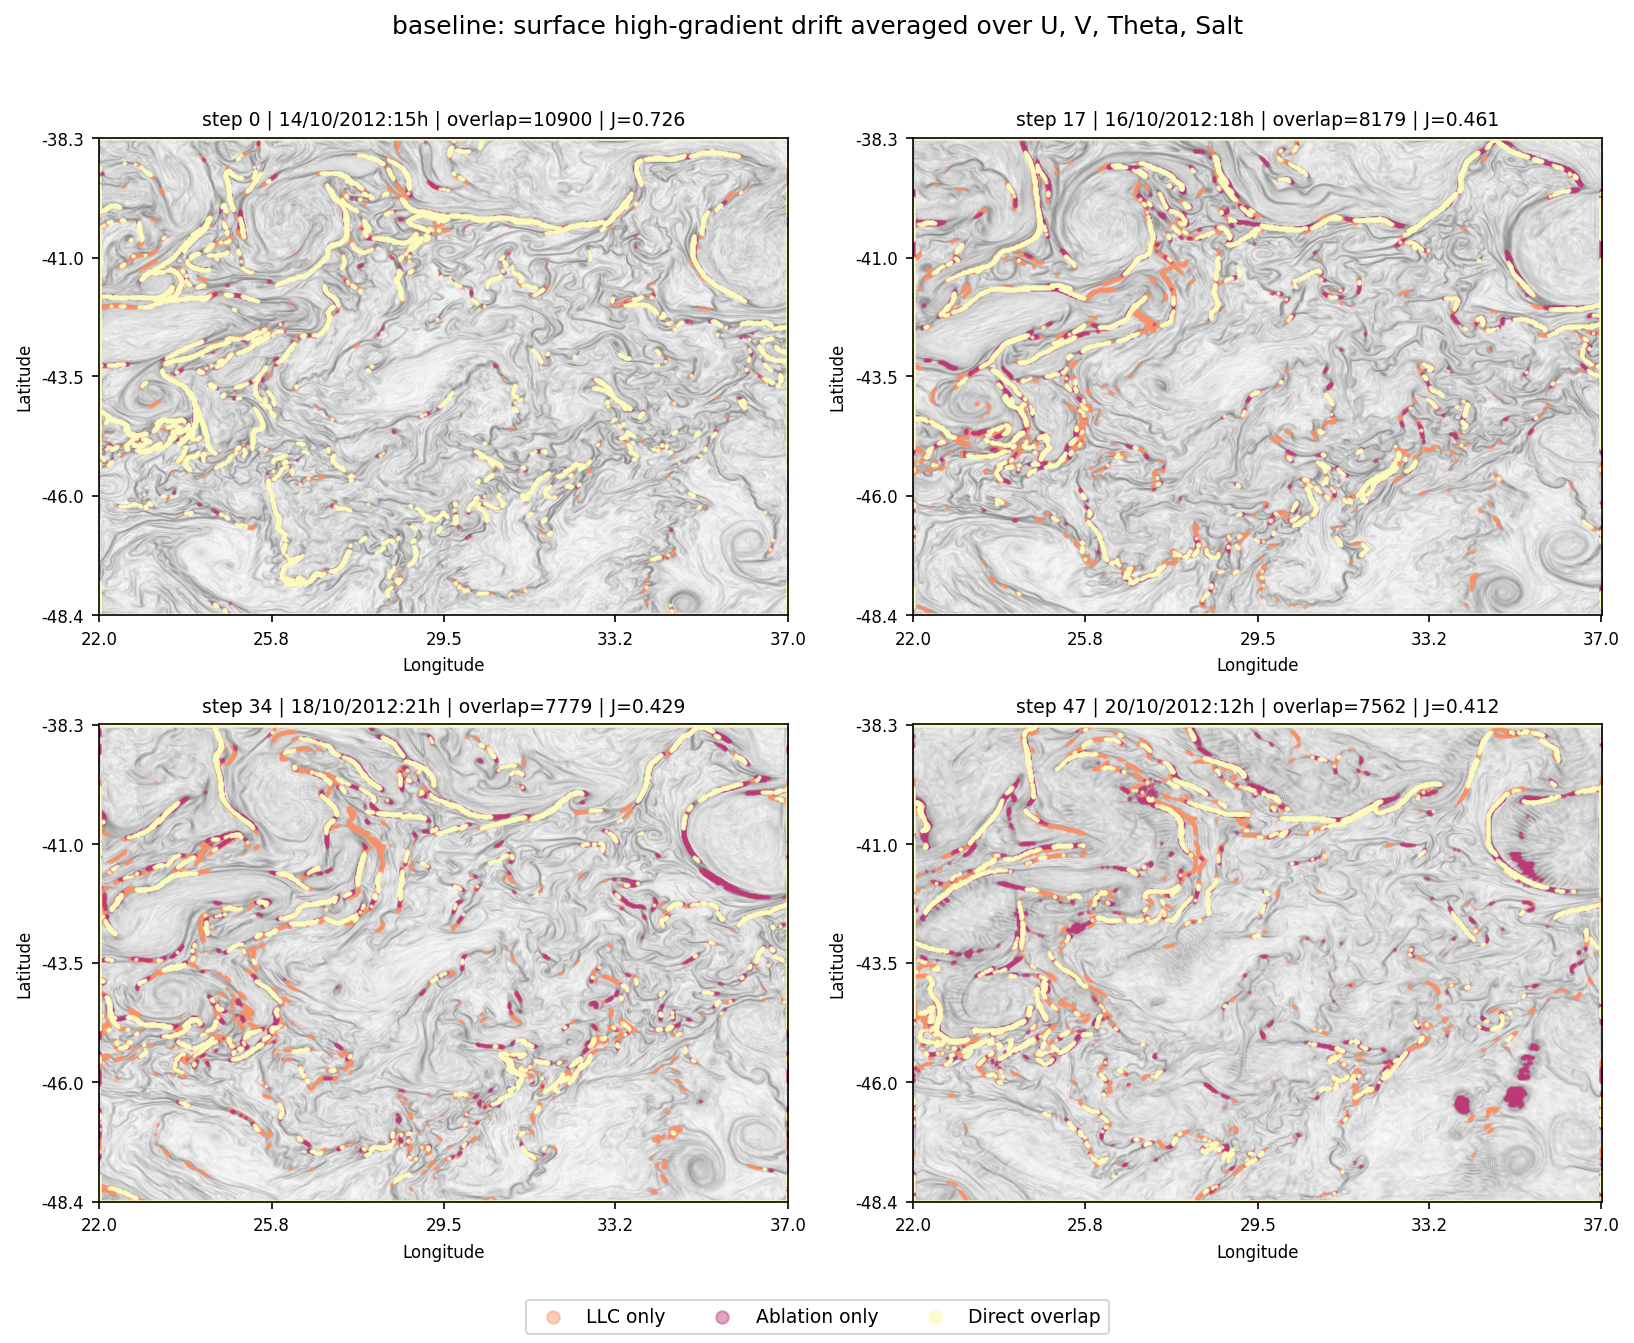

Saved figs/ablations/gradient_drift/baseline_surface_avg_gradient_drift.png
Generating gradient-drift snapshots for middle_core_off...


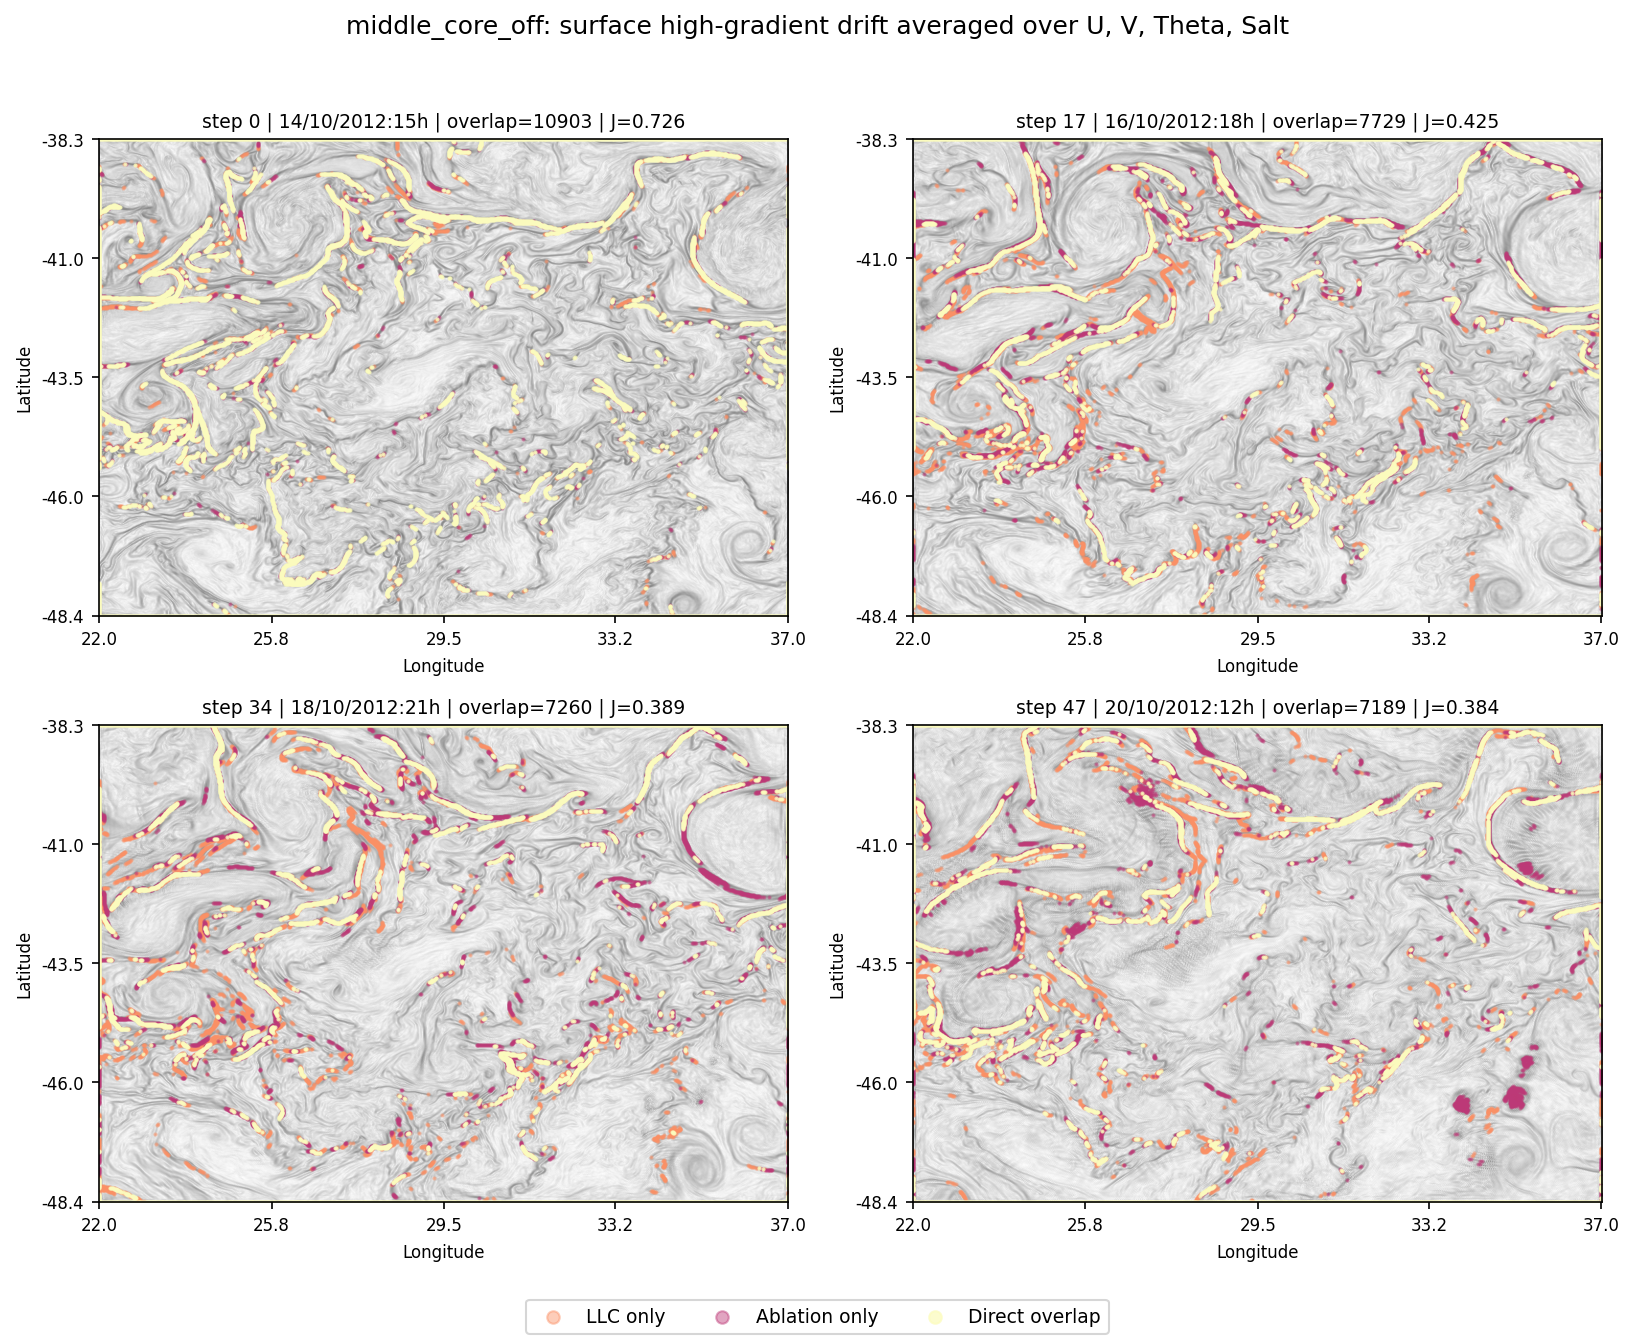

Saved figs/ablations/gradient_drift/middle_core_off_surface_avg_gradient_drift.png
Generating gradient-drift snapshots for skip_all_off...


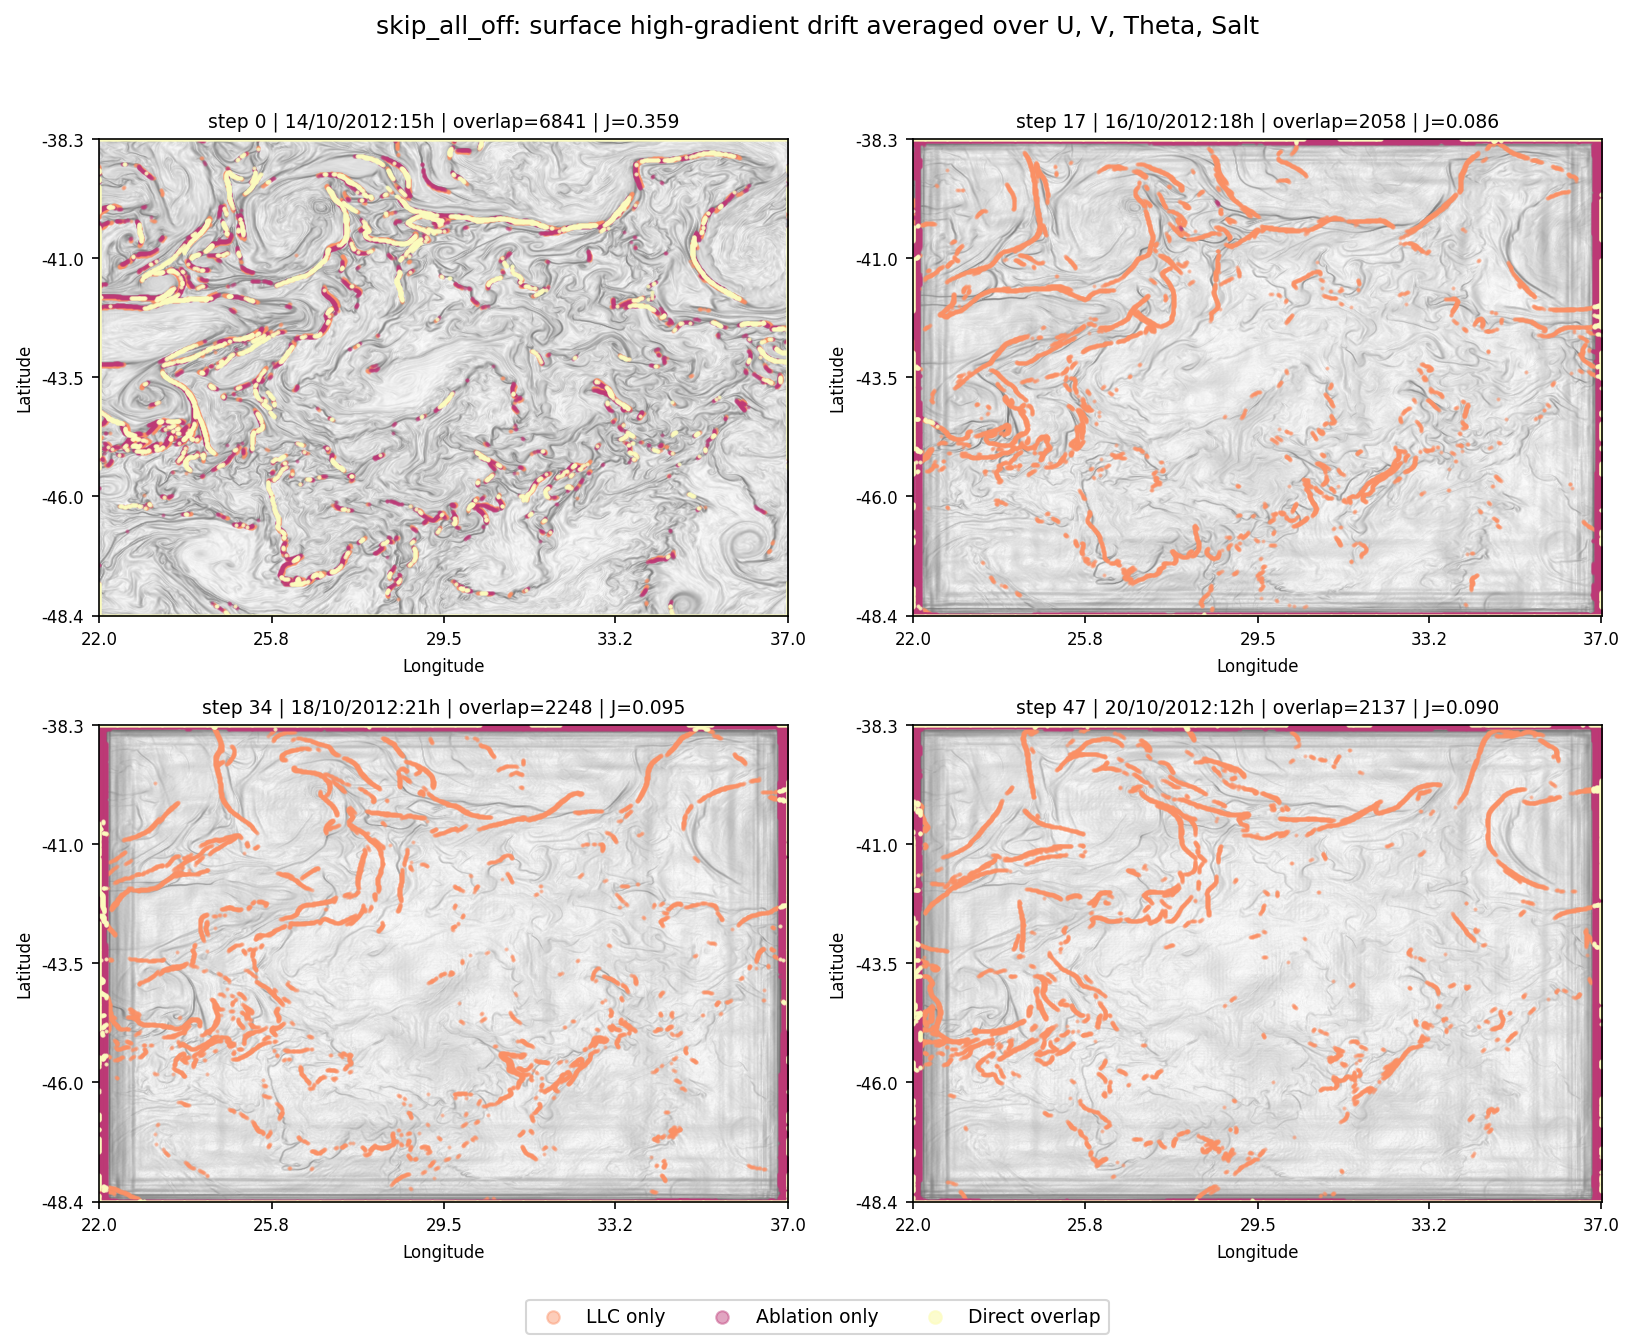

Saved figs/ablations/gradient_drift/skip_all_off_surface_avg_gradient_drift.png


In [17]:
def plot_gradient_drift_by_emulator(snapshot_steps=gradient_snapshot_steps):
    drift_dir = out_dir / 'gradient_drift'
    drift_dir.mkdir(parents=True, exist_ok=True)

    sample_mask = gradient_masks['llc'][snapshot_steps[0]]
    n_j, n_i = sample_mask.shape
    j_vals = np.arange(n_j)
    i_vals = np.arange(n_i)
    xc_block = _coord_block(llc_patch, 'XC', n_j, n_i)
    yc_block = _coord_block(llc_patch, 'YC', n_j, n_i)
    x_tick_pos, x_tick_labels = _nice_lon_lat_ticks(xc_block, i_vals, 'i')
    y_tick_pos, y_tick_labels = _nice_lon_lat_ticks(yc_block, j_vals, 'j')

    for emu_name, emu_key in emulator_info:
        print(f'Generating gradient-drift snapshots for {emu_name}...')
        fig, axes = plt.subplots(2, 2, figsize=(11, 9), dpi=150)
        axes = axes.ravel()

        for ax, t in zip(axes, snapshot_steps):
            llc_mask = gradient_masks['llc'][t]
            emu_mask = gradient_masks[emu_key][t]
            emu_grad = gradient_fields[emu_key][t]

            overlap_mask = llc_mask & emu_mask
            llc_only_mask = llc_mask & ~emu_mask
            emu_only_mask = emu_mask & ~llc_mask
            union_mask = llc_mask | emu_mask

            background = np.log10(emu_grad + np.nanpercentile(emu_grad, 1) + 1e-30)
            ax.imshow(background, cmap='Greys', aspect='auto', origin='lower')

            llc_j, llc_i = np.where(llc_only_mask)
            emu_j, emu_i = np.where(emu_only_mask)
            ovl_j, ovl_i = np.where(overlap_mask)

            ax.scatter(llc_i, llc_j, c=drift_colours['llc_only'], s=1, alpha=0.45, label='LLC only', rasterized=True)
            ax.scatter(emu_i, emu_j, c=drift_colours['emu_only'], s=1, alpha=0.45, label='Ablation only', rasterized=True)
            ax.scatter(ovl_i, ovl_j, c=drift_colours['overlap'], s=1, alpha=0.75, label='Direct overlap', rasterized=True)

            n_overlap = int(overlap_mask.sum())
            n_union = int(union_mask.sum())
            jaccard = n_overlap / n_union if n_union else np.nan
            time_str = format_time(llc_patch.time.values[t])
            ax.set_title(f'step {t} | {time_str} | overlap={n_overlap} | J={jaccard:.3f}', fontsize=9)

            ax.set_xticks(x_tick_pos)
            ax.set_xticklabels(x_tick_labels, fontsize=8)
            ax.set_yticks(y_tick_pos)
            ax.set_yticklabels(y_tick_labels, fontsize=8)
            ax.set_xlabel('Longitude', fontsize=8)
            ax.set_ylabel('Latitude', fontsize=8)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, markerscale=6)
        fig.suptitle(
            f'{emu_name}: surface high-gradient drift averaged over U, V, Theta, Salt',
            fontweight='bold',
        )
        plt.tight_layout(rect=[0, 0.04, 1, 0.96])

        safe_key = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in emu_key)
        out_path = drift_dir / f'{safe_key}_surface_avg_gradient_drift.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved {out_path}')


plot_gradient_drift_by_emulator(gradient_snapshot_steps)
